# Drift and genetic diversity

Why does neutral variation disappear faster in a small population?

In a diploid population, an allele at frequency $p$ occupies some of the $2N$ copies of a locus. Each generation draws a new set of copies. Even if the allele has no fitness effect, its frequency changes by chance.

The essential distinction is between the **mean** frequency across many populations and the **variation** among those populations. Neutral drift leaves the mean unchanged but spreads the frequencies apart. At the boundaries, an allele is either lost or fixed.

## A small model

Let $K_{t+1}$ be the number of copies of the allele in the next generation. The Wright–Fisher model says

$$
K_{t+1}\mid p_t \sim \operatorname{Binomial}(2N,p_t),
\qquad p_{t+1}=K_{t+1}/(2N).
$$

Thus $E[p_{t+1}\mid p_t]=p_t$, while
$\operatorname{Var}(p_{t+1}\mid p_t)=p_t(1-p_t)/(2N)$.
The same sampling step produces larger fluctuations when $N$ is smaller.

For two randomly drawn copies, expected heterozygosity is $H_t=2p_t(1-p_t)$. Without mutation or migration, its mean across populations falls by a factor $1-1/(2N)$ each generation. We should see nearly the same **mean allele frequency** in small and large populations, but a faster loss of diversity in small populations.

## Follow the same allele in many populations

Each column below is an independent population that starts at $p_0=0.5$. The only difference is population size.

In [1]:
simulate_drift <- function(n_diploid, n_pop, generations, p0) {
  frequency <- matrix(NA_real_, nrow = generations + 1, ncol = n_pop)
  frequency[1, ] <- p0
  for (t in seq_len(generations)) {
    frequency[t + 1, ] <- rbinom(
      n_pop, size = 2 * n_diploid, prob = frequency[t, ]
    ) / (2 * n_diploid)
  }
  frequency
}

set.seed(8149)
p0 <- 0.5
generations <- 60
small <- simulate_drift(n_diploid = 20, n_pop = 300, generations, p0)
large <- simulate_drift(n_diploid = 200, n_pop = 300, generations, p0)
stopifnot(all(small >= 0 & small <= 1), all(large >= 0 & large <= 1))

The thin lines show individual small populations. The right panel averages heterozygosity across all 300 populations of each size. The dashed curves are the model's prediction, not a fit to the simulations.

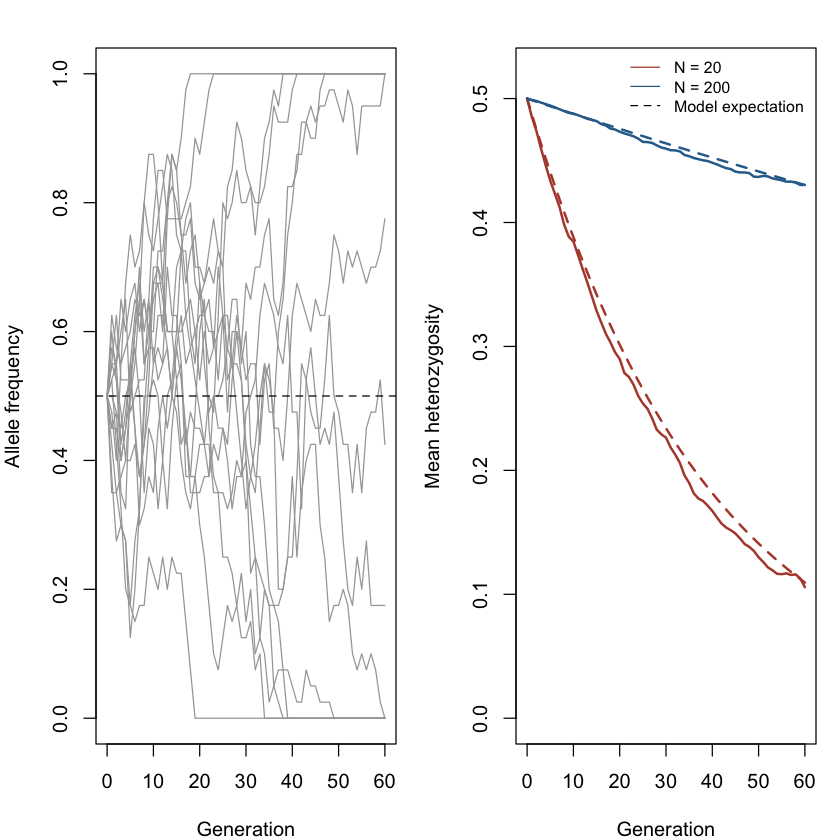

In [2]:
time <- 0:generations
mean_h <- function(frequency) rowMeans(2 * frequency * (1 - frequency))
predicted_h <- function(n_diploid) {
  2 * p0 * (1 - p0) * (1 - 1 / (2 * n_diploid))^time
}

old_par <- par(mfrow = c(1, 2), mar = c(4, 4, 2, 1), bg = "white")
matplot(time, small[, 1:15], type = "l", lty = 1, col = "grey65",
        xlab = "Generation", ylab = "Allele frequency", ylim = c(0, 1))
abline(h = p0, col = "black", lty = 2)
plot(time, mean_h(small), type = "l", lwd = 2, col = "#B44A3A",
     xlab = "Generation", ylab = "Mean heterozygosity", ylim = c(0, 0.52))
lines(time, predicted_h(20), col = "#B44A3A", lty = 2, lwd = 2)
lines(time, mean_h(large), col = "#306C9A", lwd = 2)
lines(time, predicted_h(200), col = "#306C9A", lty = 2, lwd = 2)
legend("topright", c("N = 20", "N = 200", "Model expectation"),
       col = c("#B44A3A", "#306C9A", "black"), lty = c(1, 1, 2),
       bty = "n", cex = 0.8)
par(old_par)

The mean allele frequency can stay near 0.5 even after many individual populations have moved far from it. Heterozygosity tells us what happens **within** a population; the mean frequency alone does not.

The exact decline factor also provides a check on the code. Sampling variation means that 300 simulated populations need not land exactly on the dashed curves.

In [3]:
data.frame(
  population = c("N = 20", "N = 200"),
  mean_frequency = round(c(mean(small[61, ]), mean(large[61, ])), 3),
  mean_heterozygosity = round(c(mean_h(small)[61], mean_h(large)[61]), 3),
  model_heterozygosity = round(c(predicted_h(20)[61], predicted_h(200)[61]), 3)
)

population,mean_frequency,mean_heterozygosity,model_heterozygosity
<chr>,<dbl>,<dbl>,<dbl>
N = 20,0.540,0.106,0.109
N = 200,0.504,0.430,0.430


## What to remember

Finite sampling changes neutral allele frequencies. Smaller $N$ makes each step noisier, so diversity is lost faster. This is the forward-time view of drift; looking backward at sampled copies leads to coalescence.

**Sources.** Pritchard, *An Owner's Guide to the Human Genome*, Section 2.1, especially Fig. 2.9; Gorroochurn, *Population Genetics Notes*, Sections 8.2–8.5. The simulation here is a small original illustration of their Wright–Fisher model (seed 8149; $N=20$ or $200$; 300 populations; 60 generations). It is not a transcription of book code.